In [18]:
import numpy as np
import scipy

import matplotlib.pyplot as plt 
%matplotlib inline

# VG-процесс

Рассмотрим сначала гамма-процесс. Он имеет меру Леви с плотностью

$$
f_\nu(y) = \beta\frac{e^{-\alpha y}}{y} \mathbb{1}(y>0)
$$

и характеристическую экспоненту

$$
\Psi_X(\xi) = -\alpha \ln (1 - i\xi/\beta).
$$

По построению это всего лишь процесс с независимыми приращениями

$$
X_{t} - X_{s} \sim \Gamma(\alpha (t-s), \beta ).
$$

Траектории такого процесса неубывают, это связано с тем, что приращения почти наверное положительные.





In [19]:
class GammaProcess:
    
    def __init__(self, alpha, beta):
        self.alpha = alpha
        self.beta = beta
        
    def sampleTrajs(self, x0, N, ts):
        '''
        Samples N trajectories of the process on range [0,T]
    
        Parameters
        float x0 -- start
        int N -- number of trajectories
        float[] ts -- the observation times
    
        Returns
        xs -- (N,len(ts))
        '''

        xs=np.zeros([N,len(ts)])
        xs[:,0]=x0
        for kk in np.arange(1,len(ts)):
            noises=np.random.gamma(shape=self.alpha*(ts[kk]-ts[kk-1]),scale=(self.beta), size=(N,))
            xs[...,kk]=xs[...,kk-1] + noises
    
        return xs
    

In [20]:
x0=0

alpha=15#shape
beta=5#rate?
N=10
T=3
Nt=10000
ts = np.arange(0,T+T/(2*Nt), T/Nt)

gamProc = GammaProcess(alpha,beta)
trajs = gamProc.sampleTrajs(x0,N,ts)


#print(trajs, times)

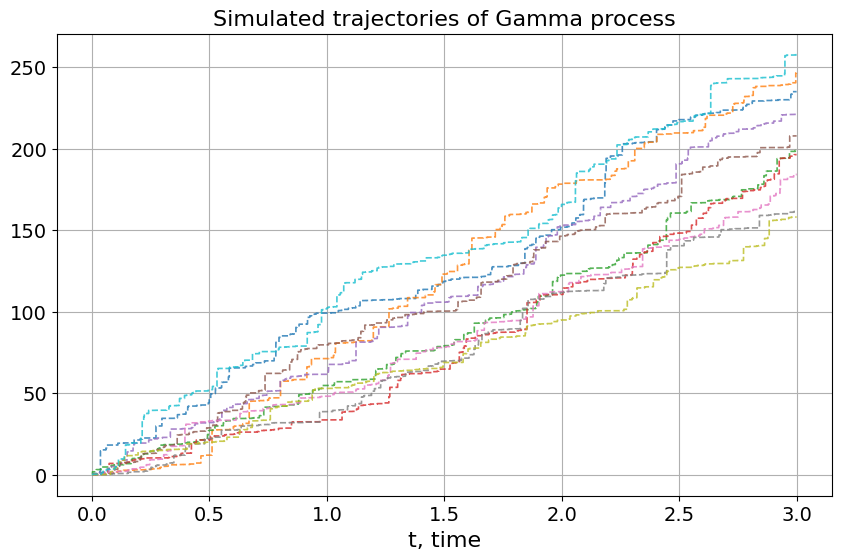

In [21]:
f, ax = plt.subplots(figsize=(10,6))

ax.grid()
ax.set_title('Simulated trajectories of Gamma process',fontsize=16)
ax.set_xlabel('t, time',fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.step(ts,trajs.T,"--",where="post", linewidth=1.2, alpha=0.8)

Сам по себе гамма-процесс не так интересен, потому что это что-то похожее на Пуассоновский процесс...хотя посложнее. Но мы его используем для того, чтобы построить ещё одну ценовую модель, которую можно использовать для оценки опционов. 

Variance-Gamma -- это простейший процесс Леви с бесконечной интенсивностью прыжков и который двигается только за счёт прыжков: гауссовской компоненты у него нет. Процесс имеет характеристическую экспоненту

$$
\Psi(\xi) = -\alpha \ln\left( 1 - i \delta \xi  + \delta\xi^2/2 \right), \quad \alpha,\gamma \in \mathbb{R}, ~ \delta>0
$$

и изначально авторами предлагался в виде

$$
Y_t = \mu X_t + \sigma W_{X_t},
$$

где $X$ -- это гамма-процесс, а $W$ -- Винеровский процесс. Можете попробовать явно найти как выражаются параметры харфукнции через параметры процессов, используя то же рассуждение, как мы делали на лекции, это несложно; разные авторы вводят эти параметры по-разному.


In [22]:
class WienerDriftProcess:
    
    def __init__(self, gamma=0, sigma=1):
        self.gamma = gamma
        self.sigma = sigma
        
    def sampleTrajs(self,x0,ts,N):
        '''
        Simulates trajectories of Wiener process
        Input
        float x0 -- initial value
        float[] ts -- times
        int N -- number of trajectories to simulate
        Returns
        float[] of shape (Ntraj,xs.shape[0],len(ts))
        '''
        if(len(ts.shape)==1):
            ts = ts.unsqueeze(0)
            print("AAAAAA")
            
        
        xs=np.zeros_like(ts)
        print(ts.shape, xs.shape)
        xs[...,0]=x0
        for kk in np.arange(1,ts.shape[1]):
            noises=np.random.standard_normal(size=(N,))
            xs[...,kk]=xs[...,kk-1] + self.sigma*np.sqrt(ts[:,kk]-ts[:,kk-1])*noises
    
        return xs + self.gamma*ts
    
class VarianceGammaProcess:
    
    def __init__(self, alpha, beta, mu, sigma):
        self.gammaProc = GammaProcess(alpha=alpha,beta=beta)
        self.wienProc = WienerDriftProcess()
        self.mu = mu
        self.sigma = sigma
        
    def sampleTrajs(self, x0, N, ts):
        '''
        Samples N trajectories of the process on range [0,T]
    
        Parameters
        float x0 -- start
        int N -- number of trajectories
        float[] ts -- the observation times
    
        Returns
        xs -- (N,len(ts))
        '''
        gammaProc = self.gammaProc.sampleTrajs(0,N,ts)
        xs = x0+ self.mu*gammaProc + self.sigma * self.wienProc.sampleTrajs(0,gammaProc,N)
        print(xs[:,0])
        return xs
        
    

In [25]:
x0=3

alpha=300 #~~~~~~~~ quite large jumps possible
beta=1/(360*5) #~~~~~~every day several jumps on average
#average gamma-increment alpha/beta
mu=-0.1
sigma=0.2

N=10
T=1
Nt=10000
ts = np.arange(0,T+T/(2*Nt), T/Nt)

gamProc = VarianceGammaProcess(alpha,beta, mu, sigma)
trajs = gamProc.sampleTrajs(x0,N,ts)


#print(trajs, times)

(10, 10001) (10, 10001)
[3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]


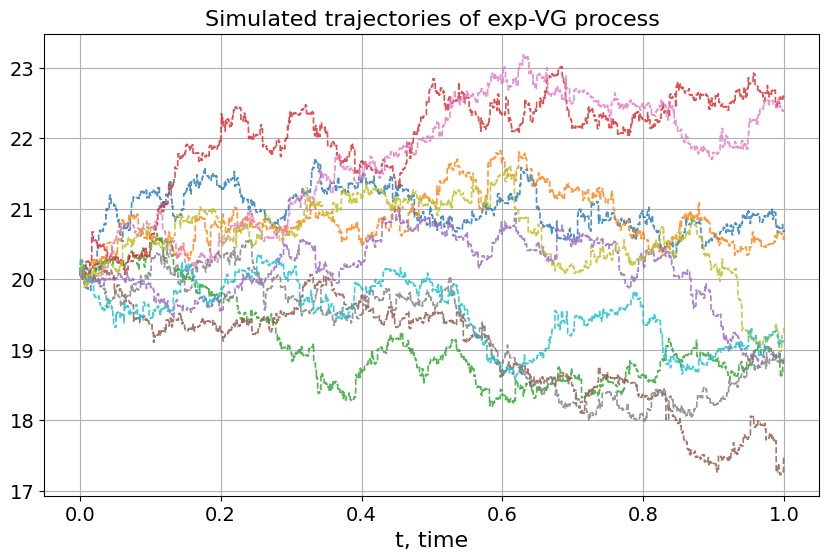

In [26]:
f, ax = plt.subplots(figsize=(10,6))

ax.grid()
ax.set_title('Simulated trajectories of exp-VG process',fontsize=16)
ax.set_xlabel('t, time',fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
#ax.step(ts,trajs.T,"--",where="post", linewidth=1.2, alpha=0.8)
ax.step(ts,np.exp(trajs).T,"--",where="post", linewidth=1.2, alpha=0.8)
#ax.set_yscale("log")

Удивительно, но это только за счёт прыжков.

Подробнее про VG-процесс можно прочитать в оригинальной [статье Мадана,Карра и Чанга (1998)](https://engineering.nyu.edu/sites/default/files/2018-09/CarrEuropeanFinReview1998.pdf) и в [статье Даала и Мадана (2005)](https://www.jstor.org/stable/10.1086/497039?seq=19).

КОММЕНТАРИЙ: По сравнению с версией 2024, здесь исправлена ошибка в определении гамма процесса $(t-s)$ делается по первому аргументу. Это всё ещё процесс с бесконечной интенсивностью который двигает за счёт прыжков, но иллюстрация траекторий была ошибочна и я очень рад, что смог её исправить (МК).